# Automated Model Evaluation Pipeline

## TASK
Set up automated model evaluation pipeline:
- Runs nightly
- Stores Accuracy / F1 / AUC metrics
- Saves metrics into database table

## DATASET
`claim_data.csv`

## STEP 1 — INSTALL REQUIRED LIBRARIES

Run these commands in terminal first:

```bash
pip install pandas
pip install numpy
pip install scikit-learn
pip install sqlalchemy
pip install joblib
pip install schedule
```

It seems `schedule` was not installed. Let's install it explicitly before importing libraries.

In [10]:
!pip install schedule

!pip install schedule

In [11]:
import pandas as pd
import numpy as np
import joblib
import schedule
import time
import logging

from datetime import datetime

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from sqlalchemy import create_engine
from sqlalchemy import text

## STEP 3 — LOGGING SETUP

In [12]:
logging.basicConfig(
    filename='evaluation.log',
    filemode='a',
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s'
)

print("Logging Setup Completed!")

Logging Setup Completed!


## STEP 4 — DATABASE CONNECTION

In [13]:
# SQLite database will be created automatically

engine = create_engine(
    "sqlite:///insurance.db"
)

print("Database Connected Successfully!")

Database Connected Successfully!


## STEP 5 — CREATE METRICS TABLE

In [14]:
create_table_query = """
CREATE TABLE IF NOT EXISTS model_metrics (

    id INTEGER PRIMARY KEY AUTOINCREMENT,

    model_name TEXT,

    accuracy FLOAT,

    f1_score FLOAT,

    auc_score FLOAT,

    evaluated_at TIMESTAMP
);
"""

with engine.connect() as connection:

    connection.execute(text(create_table_query))
    connection.commit()

print("Metrics Table Ready!")

Metrics Table Ready!


## STEP 6 — LOAD DATASET

In [15]:
# Make sure claim_data.csv is in same folder

data = pd.read_csv("claim_data.csv")

print("\nDataset Loaded Successfully!")

print("\nDataset Shape:")
print(data.shape)

print("\nFirst 5 Rows:")
display(data.head())


Dataset Loaded Successfully!

Dataset Shape:
(1000, 15)

First 5 Rows:


,Claim ID,Provider ID,Patient ID,Date of Service,Billed Amount,Procedure Code,Diagnosis Code,Allowed Amount,Paid Amount,Insurance Type,Claim Status,Reason Code,Follow-up Required,AR Status,Outcome
0,0HO1FSN4AP,126528997,7936697103,08/07/2024,304,99231,A02.1,218,203,Self-Pay,Paid,Incorrect billing information,Yes,Pending,Partially Paid
1,9U86CI2P5A,6986719948,1547160031,06/21/2024,348,99213,A16.5,216,206,Medicare,Paid,Pre-existing condition,Yes,Open,Denied
2,1QEU1AIDAU,1355108115,2611585318,07/04/2024,235,99213,A00.1,148,119,Commercial,Under Review,Duplicate claim,No,Denied,Denied
3,WH7XDS8CEO,9991055906,7167948632,05/26/2024,112,99215,A18.6,79,69,Medicare,Denied,Authorization not obtained,No,Partially Paid,Denied
4,M6OJEZ8KGI,7382167012,2140226267,07/16/2024,406,99238,A17.9,320,259,Medicare,Denied,Authorization not obtained,No,On Hold,Denied


## STEP 7 — DATA PREPROCESSING

In [16]:
print("\nStarting Data Preprocessing...")

# ------------------------------------------------------------
# Remove Missing Values
# ------------------------------------------------------------

data = data.dropna()


# ------------------------------------------------------------
# Convert Target Variable
# ------------------------------------------------------------

# Paid = 1
# Denied = 0
# Under Review = 0

data['Claim Status'] = data['Claim Status'].replace({

    'Paid': 1,

    'Denied': 0,

    'Under Review': 0
})


# ------------------------------------------------------------
# Encode Categorical Columns
# ------------------------------------------------------------

label_encoder = LabelEncoder()

categorical_columns = data.select_dtypes(
    include=['object']
).columns

for column in categorical_columns:

    if column != 'Claim Status':

        data[column] = label_encoder.fit_transform(
            data[column]
        )

print("Data Preprocessing Completed!")


Starting Data Preprocessing...
Data Preprocessing Completed!


/tmp/ipykernel_10507/2877021496.py:18: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['Claim Status'] = data['Claim Status'].replace({


## STEP 8 — FEATURE SELECTION

In [17]:
target = 'Claim Status'

X = data.drop(columns=[target])

y = data[target]

print("\nFeatures and Target Selected!")


Features and Target Selected!


## STEP 9 — TRAIN TEST SPLIT

In [18]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42
)

print("\nTrain-Test Split Completed!")

print("Training Data Shape:", X_train.shape)

print("Testing Data Shape:", X_test.shape)


Train-Test Split Completed!
Training Data Shape: (800, 14)
Testing Data Shape: (200, 14)


## STEP 10 — MODEL TRAINING

In [19]:
print("\nTraining Random Forest Model...")

model = RandomForestClassifier(

    n_estimators=100,

    random_state=42
)

model.fit(X_train, y_train)

print("Model Training Completed!")


Training Random Forest Model...
Model Training Completed!


## STEP 11 — SAVE MODEL

In [20]:
joblib.dump(
    model,
    "claim_classifier.pkl"
)

print("Model Saved Successfully!")

Model Saved Successfully!


## STEP 12 — MODEL EVALUATION FUNCTION

In [32]:
def evaluate_model():

    print("\n===================================")
    print("RUNNING MODEL EVALUATION PIPELINE")
    print("===================================")

    # --------------------------------------------------------
    # Load Saved Model
    # --------------------------------------------------------

    model = joblib.load(
        "claim_classifier.pkl"
    )

    # --------------------------------------------------------
    # Make Predictions
    # --------------------------------------------------------

    y_pred = model.predict(X_test)

    y_prob = model.predict_proba(X_test)[:, 1]

    # --------------------------------------------------------
    # Calculate Metrics
    # --------------------------------------------------------

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    f1 = f1_score(
        y_test,
        y_pred
    )

    auc = roc_auc_score(
        y_test,
        y_prob
    )

    # --------------------------------------------------------
    # Print Metrics
    # --------------------------------------------------------

    print("\n========== MODEL PERFORMANCE ==========")

    print(f"\nAccuracy Score : {accuracy:.4f}")

    print(f"F1 Score       : {f1:.4f}")

    print(f"AUC ROC Score  : {auc:.4f}")

    # --------------------------------------------------------
    # Confusion Matrix
    # --------------------------------------------------------

    print("\nConfusion Matrix:")

    print(
        confusion_matrix(
            y_test,
            y_pred
        )
    )

    # --------------------------------------------------------
    # Classification Report
    # --------------------------------------------------------

    print("\nClassification Report:")

    print(
        classification_report(
            y_test,
            y_pred
        )
    )

    # --------------------------------------------------------
    # Create Metrics DataFrame
    # --------------------------------------------------------

    metrics_df = pd.DataFrame({

        "model_name": [
            "RandomForest Claim Classifier"
        ],

        "accuracy": [accuracy],

        "f1_score": [f1],

        "auc_score": [auc],

        "evaluated_at": [datetime.datetime.now()]
    })

    # --------------------------------------------------------
    # Store Metrics in Database
    # --------------------------------------------------------

    metrics_df.to_sql(

        "model_metrics",

        engine,

        if_exists="append",

        index=False
    )

    print("\nMetrics Stored in Database Successfully!")

    # --------------------------------------------------------
    # Logging
    # --------------------------------------------------------

    logging.info(

        f"Accuracy={accuracy}, "
        f"F1={f1}, "
        f"AUC={auc}"
    )

    logging.info(
        "Evaluation Pipeline Executed Successfully"
    )

    print("Evaluation Logged Successfully!")

    print("\nPipeline Execution Completed!")

## STEP 13 — RUN EVALUATION ONCE

In [23]:
evaluate_model()


RUNNING MODEL EVALUATION PIPELINE

========== MODEL PERFORMANCE ==========

Accuracy Score : 0.6400
F1 Score       : 0.0526
AUC ROC Score  : 0.4940

Confusion Matrix:
[[126   8]
 [ 64   2]]

Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.94      0.78       134
           1       0.20      0.03      0.05        66

    accuracy                           0.64       200
   macro avg       0.43      0.49      0.42       200
weighted avg       0.51      0.64      0.54       200


Metrics Stored in Database Successfully!
Evaluation Logged Successfully!

Pipeline Execution Completed!


## STEP 14 — NIGHTLY AUTOMATION

In [34]:
import datetime

# Set the scheduled time to 11:00 AM
formatted_time = "11:00"

# Clear existing jobs to avoid multiple schedules
schedule.clear()

schedule.every().day.at(formatted_time).do(
    evaluate_model
)

print(f"\nScheduler Started Successfully!")
print(f"Pipeline will run every day at {formatted_time}")


Scheduler Started Successfully!
Pipeline will run every day at 11:00


## STEP 15 — KEEP SCRIPT RUNNING

In [38]:
while True:

    schedule.run_pending()

    time.sleep(60)

KeyboardInterrupt: 

In [37]:
print("Current Scheduled Jobs:")
for job in schedule.get_jobs():
    print(job)

Current Scheduled Jobs:
Job(interval=1, unit=days, do=evaluate_model, args=(), kwargs={})


## View Stored Metrics

In [40]:
try:
    # Establish a new connection to the database
    with engine.connect() as connection:
        # Read the model_metrics table into a pandas DataFrame
        metrics_df = pd.read_sql_table('model_metrics', con=connection)

    print("Metrics from 'model_metrics' table:")
    display(metrics_df)

except Exception as e:
    print(f"An error occurred while trying to read the database: {e}")

Metrics from 'model_metrics' table:


,id,model_name,accuracy,f1_score,auc_score,evaluated_at
0,1,RandomForest Claim Classifier,0.64,0.052632,0.494007,2026-05-10 18:01:11.995166


/tmp/ipykernel_10507/696095244.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=metric_names, y=metric_values, palette='viridis')


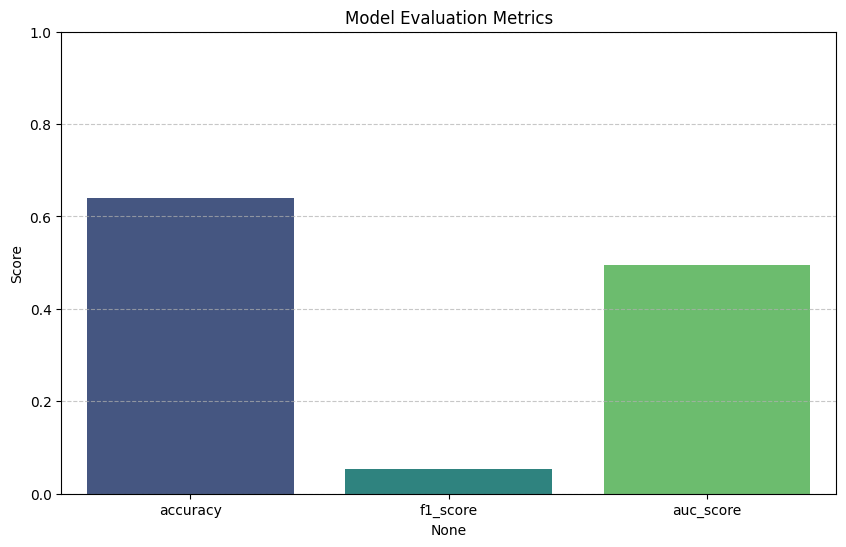

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

# Extract metrics for visualization
metrics = metrics_df[['accuracy', 'f1_score', 'auc_score']].iloc[0]
metric_names = metrics.index
metric_values = metrics.values

# Create a bar plot
plt.figure(figsize=(10, 6))
sns.barplot(x=metric_names, y=metric_values, palette='viridis')
plt.title('Model Evaluation Metrics')
plt.ylabel('Score')
plt.ylim(0, 1) # Metrics are typically between 0 and 1
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()